In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import unicodedata

file_path = 'https://raw.githubusercontent.com/onrhoza/dsc-group-assignment/refs/heads/main/SAD-IV.NCHLT_Lemma-Morph-POS.Final_TRAIN.2026-03-31.nr.txt'
column_names = ['word', 'lemma', 'morphemes', 'pos', 'features']

try:
    # Try reading with one or more spaces as delimiter, no header, and specified column names.
    df = pd.read_csv(
        file_path,
        sep=r'\s+',
        header=None,
        names=column_names,
        engine='python',
        quotechar=None,
        on_bad_lines='warn'
    )
    print("Successfully loaded dataset with whitespace delimiter.")
except Exception as e:
    print(f"Failed to load dataset with expected 5 columns: {e}")
    print("Attempting to load as a single column 'raw_text' for manual inspection.")
    # Fallback: if parsing into 5 columns fails, load as a single raw text column.
    df = pd.read_csv(file_path, header=None, names=['raw_text'], engine='python', on_bad_lines='warn')
    print("""Loaded as 'raw_text' column. Manual parsing will be required to extract specific fields.
Consider inspecting the file content and `sep` parameter.""")

# --- DIAGNOSTIC PRINTS START ---
print("\n--- DataFrame state after initial load (before cleaning) ---")
print("DataFrame head:")
print(df.head())
print("\nNull values per column:")
print(df.isnull().sum())
print("--- DIAGNOSTIC PRINTS END ---\n")
# --- DIAGNOSTIC PRINTS END ---

# Step 1: Clean dataset
# Filter out rows where 'word' column indicates metadata (e.g., '<LINE 0001>')
df = df[~df['word'].astype(str).str.startswith('<LINE')]

# Only drop rows if 'word' or 'lemma' are missing, as these are critical
df = df.dropna(subset=['word','lemma'])
df = df.drop_duplicates()
df['word'] = df['word'].apply(lambda x: unicodedata.normalize("NFC", str(x)))

# Add a check here in case df is still empty after cleaning
if df.empty:
    print("Error: DataFrame is empty after cleaning steps. Please inspect the raw data and cleaning logic.")
else:
    # Step 2: Split by unique words (leakage-free)
    unique_words = df['word'].unique()
    if len(unique_words) == 0:
        print("Error: No unique words found after cleaning. Cannot split data.")
    else:
        train_words, test_words = train_test_split(unique_words, test_size=0.1, random_state=42)
        train_words, val_words = train_test_split(train_words, test_size=0.1, random_state=42)

        train_df = df[df['word'].isin(train_words)]
        val_df = df[df['word'].isin(val_words)]
        test_df = df[df['word'].isin(test_words)]

        print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")

        # Step 3: Convert to instruction-output pairs
        def format_example(row):
            # Handle potential None/NaN values gracefully for output fields
            morphemes = row['morphemes'] if pd.notna(row['morphemes']) else ''
            pos = row['pos'] if pd.notna(row['pos']) else ''
            features = row['features'] if pd.notna(row['features']) else ''

            instruction = f"Analyse the isiNdebele word: {row['word']}"
            output = f"morphemes: {morphemes}; lemma: {row['lemma']}; pos: {pos}; features: {features}"
            return {"instruction": instruction, "output": output}

        train_dataset = train_df.apply(format_example, axis=1).tolist()
        val_dataset = val_df.apply(format_example, axis=1).tolist()
        test_dataset = test_df.apply(format_example, axis=1).tolist()

        # ------------------------------
        # GPT-2 pipeline
        # ------------------------------

        from transformers import AutoTokenizer, AutoModelForCausalLM

        MODEL = "gpt2"  # baseline small model
        tokenizer = AutoTokenizer.from_pretrained(MODEL)
        model = AutoModelForCausalLM.from_pretrained(MODEL)

        from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
        from datasets import Dataset

        # Tokenize dataset
        def tokenize(batch):
            concatenated_text = [f'{inst} {out}' for inst, out in zip(batch['instruction'], batch['output'])]
            tokenized_inputs = tokenizer(concatenated_text, truncation=True)
            return tokenized_inputs

        # Convert lists to Dataset objects
        train_dataset = Dataset.from_list(train_dataset)
        val_dataset = Dataset.from_list(val_dataset)

        # Apply tokenization
        tokenized_train_dataset = train_dataset.map(tokenize, batched=True)
        tokenized_val_dataset = val_dataset.map(tokenize, batched=True)

        # GPT2 tokenizer does not have a pad_token by default, so we need to set it.
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

        # Training arguments
        args = TrainingArguments(
            output_dir="./gpt2_isiNdebele",
            learning_rate=2e-4,
            per_device_train_batch_size=2,
            gradient_accumulation_steps=8,
            num_train_epochs=3,
            fp16=True,
            eval_strategy="epoch",
            save_strategy="epoch"
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=tokenized_train_dataset,
            eval_dataset=tokenized_val_dataset,
            data_collator=data_collator
        )

        trainer.train()

In [7]:
import torch

# Example of using the fine-tuned model for inference
inputs = tokenizer("Analyse the isiNdebele word: abantwana", return_tensors="pt")

# Move inputs to the same device as the model
if torch.cuda.is_available():
    inputs = {k: v.to('cuda') for k, v in inputs.items()}

outputs = model.generate(**inputs, max_new_tokens=50)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Analyse the isiNdebele word: abantwana morphemes: a[NPrePre2]-ba[BPre2]-ntwana[NStem]; lemma: ntwana; pos: N02; features: iba: iba; features: iba: 


In [8]:
import torch

# Check if a GPU is available to confirm the warning's context
print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


In [9]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import Dataset

# Training arguments with dataloader_pin_memory=False
args_no_pin_memory = TrainingArguments(
    output_dir="./gpt2_isiNdebele_no_pin_memory",
    learning_rate=2e-4,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    dataloader_pin_memory=False # Explicitly disable pin_memory
)

trainer_no_pin_memory = Trainer(
    model=model,
    args=args_no_pin_memory,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    data_collator=data_collator
)

print("Training with dataloader_pin_memory=False to suppress the warning...")
# trainer_no_pin_memory.train() # Uncomment to run this training example

Training with dataloader_pin_memory=False to suppress the warning...


In [10]:
model.save_pretrained("./final_gpt2_model")
tokenizer.save_pretrained("./final_gpt2_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_gpt2_model/tokenizer_config.json',
 './final_gpt2_model/tokenizer.json')

In [11]:
import gradio as gr
import re
import pandas as pd

def analyse(word):
    # Generate output from GPT-2
    inputs = tokenizer(f"Analyse the isiNdebele word: {word}", return_tensors="pt")
    outputs = model.generate(**inputs, max_new_tokens=120)
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Regex extraction (first valid occurrence only)
    morphemes_match = re.search(r"morphemes:\s*([^;]+)", decoded)
    lemma_match = re.search(r"lemma:\s*([^;]+)", decoded)
    pos_match = re.search(r"pos:\s*([^;]+)", decoded)
    features_match = re.findall(r"features:\s*([^;]+)", decoded)

    # Extract values
    morphemes = morphemes_match.group(1).strip() if morphemes_match else "Not found"
    # Clean the morphemes string by removing content in square brackets
    morphemes = re.sub(r'\[.*?\]', '', morphemes).replace('--', '-').strip('-')

    lemma = lemma_match.group(1).strip() if lemma_match else "Not found"
    pos = pos_match.group(1).strip() if pos_match else "Unknown"

    # Clean duplicate features (keep unique values only)
    if features_match:
        features = ", ".join(sorted(set([f.strip() for f in features_match])))
    else:
        features = "Not found"

    # Structured dictionary output (sorted order)
    result = {
        "Word": word,
        "Predicted category": pos,
        "Rule segmentation": morphemes,
        "Lemma": lemma,
        # "Features": features,
        "SADiLaR annotation": f"{word} → {morphemes} | {lemma} | {pos} | {features}",
        "Source": "SADiLaR corpus + GPT-2"
    }

    # Convert dictionary to vertical DataFrame (keys as one column, values as another)
    df = pd.DataFrame(list(result.items()), columns=["Field", "Result"])
    return df


# Gradio interface with Dataframe output
gr.Interface(fn=analyse, inputs="text", outputs=gr.Dataframe()).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0baafa7df81ca31571.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
import pickle

# 1. Your Python object (e.g., a dictionary, list, or machine learning model)
# This will now save the actual trained model object

# 2. Define your desired filename
filename = "IsiNdebele_Morphological_Analyser.pkl"

# 3. Save the object as a pickle file
with open(filename, "wb") as file:
    pickle.dump(model, file) # Saving the 'model' object instead of 'my_data'

print(f"File successfully saved as {filename}")

File successfully saved as IsiNdebele_Morphological_Analyser.pkl


In [ ]:
from google.colab import files

# Download the file to your local machine (Uncomment below and run to download)
# files.download("IsiNdebele_Morphological_Analyser.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


In [14]:
import pickle

# Define the filename for the analyser function
analyser_filename = "isiNdebele_Analyser_Function.pkl"

# Save the 'analyse' function as a pickle file
with open(analyser_filename, "wb") as file:
    pickle.dump(analyse, file)

print(f"Analyser function successfully saved as {analyser_filename}")

Analyser function successfully saved as isiNdebele_Analyser_Function.pkl


### Model Evaluation: Performance Metrics

In [15]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import re
import torch

# Load the fine-tuned model and tokenizer from the saved directory
# This ensures we are evaluating the saved model, not just the one in memory
loaded_tokenizer = AutoTokenizer.from_pretrained("./final_gpt2_model")
loaded_model = AutoModelForCausalLM.from_pretrained("./final_gpt2_model")

# Move model to GPU if available
if torch.cuda.is_available():
    loaded_model.to('cuda')

def predict_and_parse(instruction_text, model, tokenizer):
    inputs = tokenizer(instruction_text, return_tensors="pt")
    if torch.cuda.is_available():
        inputs = {k: v.to('cuda') for k, v in inputs.items()}

    outputs = model.generate(**inputs, max_new_tokens=120)
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    morphemes_match = re.search(r"morphemes:\s*([^;]+)", decoded)
    lemma_match = re.search(r"lemma:\s*([^;]+)", decoded)
    pos_match = re.search(r"pos:\s*([^;]+)", decoded)
    features_match = re.findall(r"features:\s*([^;]+)", decoded)

    predicted_morphemes = morphemes_match.group(1).strip() if morphemes_match else "Not found"
    predicted_morphemes = re.sub(r'\[.*?\]', '', predicted_morphemes).replace('--', '-').strip('-')
    predicted_lemma = lemma_match.group(1).strip() if lemma_match else "Not found"
    predicted_pos = pos_match.group(1).strip() if pos_match else "Unknown"
    predicted_features = ", ".join(sorted(set([f.strip() for f in features_match]))) if features_match else "Not found"

    return {
        "morphemes": predicted_morphemes,
        "lemma": predicted_lemma,
        "pos": predicted_pos,
        "features": predicted_features
    }

# Prepare to store results
predictions = []
ground_truths = []

# Make predictions on the test dataset
print("Evaluating on test dataset...")
for i, example in enumerate(test_dataset):
    instruction = example['instruction']
    ground_truth_output = example['output']

    # Parse ground truth
    gt_morphemes_match = re.search(r"morphemes:\s*([^;]+)", ground_truth_output)
    gt_lemma_match = re.search(r"lemma:\s*([^;]+)", ground_truth_output)
    gt_pos_match = re.search(r"pos:\s*([^;]+)", ground_truth_output)
    gt_features_match = re.findall(r"features:\s*([^;]+)", ground_truth_output)

    gt_morphemes = gt_morphemes_match.group(1).strip() if gt_morphemes_match else "Not found"
    gt_morphemes = re.sub(r'\[.*?\]', '', gt_morphemes).replace('--', '-').strip('-')
    gt_lemma = gt_lemma_match.group(1).strip() if gt_lemma_match else "Not found"
    gt_pos = gt_pos_match.group(1).strip() if gt_pos_match else "Unknown"
    gt_features = ", ".join(sorted(set([f.strip() for f in gt_features_match]))) if gt_features_match else "Not found"

    ground_truths.append({
        "morphemes": gt_morphemes,
        "lemma": gt_lemma,
        "pos": gt_pos,
        "features": gt_features
    })

    # Make prediction
    predicted_parsed = predict_and_parse(instruction, loaded_model, loaded_tokenizer)
    predictions.append(predicted_parsed)

    if (i + 1) % 100 == 0:
        print(f"Processed {i+1}/{len(test_dataset)} examples.")

print("Evaluation complete. Calculating metrics...")

# Calculate metrics
correct_morphemes = 0
correct_lemma = 0
correct_pos = 0
correct_features = 0
correct_overall = 0 # Exact match of all components

for gt, pred in zip(ground_truths, predictions):
    if gt['morphemes'] == pred['morphemes']:
        correct_morphemes += 1
    if gt['lemma'] == pred['lemma']:
        correct_lemma += 1
    if gt['pos'] == pred['pos']:
        correct_pos += 1
    if gt['features'] == pred['features']:
        correct_features += 1

    if gt['morphemes'] == pred['morphemes'] and \
       gt['lemma'] == pred['lemma'] and \
       gt['pos'] == pred['pos'] and \
       gt['features'] == pred['features']:
        correct_overall += 1

num_samples = len(test_dataset)

morphemes_accuracy = correct_morphemes / num_samples if num_samples > 0 else 0
lemma_accuracy = correct_lemma / num_samples if num_samples > 0 else 0
pos_accuracy = correct_pos / num_samples if num_samples > 0 else 0
features_accuracy = correct_features / num_samples if num_samples > 0 else 0
overall_accuracy = correct_overall / num_samples if num_samples > 0 else 0

print(f"\n--- Performance Metrics on Test Set ({num_samples} samples) ---")
print(f"Morphemes Accuracy: {morphemes_accuracy:.4f}")
print(f"Lemma Accuracy: {lemma_accuracy:.4f}")
print(f"POS Accuracy: {pos_accuracy:.4f}")
print(f"Features Accuracy: {features_accuracy:.4f}")
print(f"Overall Exact Match Accuracy: {overall_accuracy:.4f}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Evaluating on test dataset...
Processed 100/1561 examples.


/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


Processed 200/1561 examples.


/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


...

Processed 1400/1561 examples.


/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(
/usr/local/lib/python3.13/

Processed 1500/1561 examples.


/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


Evaluation complete. Calculating metrics...

--- Performance Metrics on Test Set (1561 samples) ---
Morphemes Accuracy: 0.5464
Lemma Accuracy: 0.7149
POS Accuracy: 0.7412
Features Accuracy: 0.0000
Overall Exact Match Accuracy: 0.0000


### Confusion Matrix for Part-of-Speech (POS) Tags

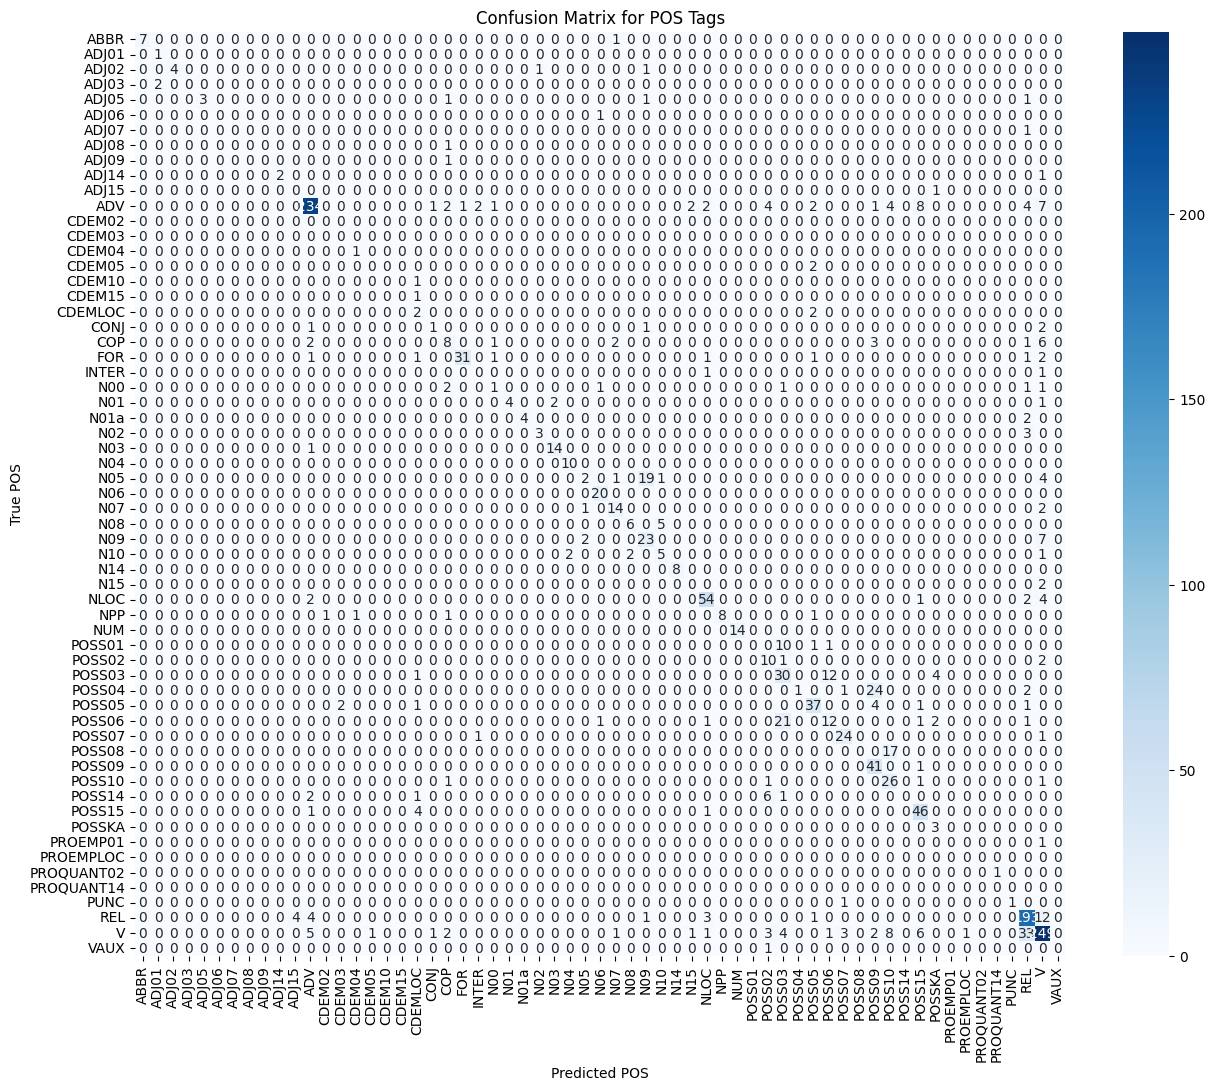

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Extract ground truth and predicted POS tags
ground_truth_pos = [gt['pos'] for gt in ground_truths]
predicted_pos = [pred['pos'] for pred in predictions]

# Get all unique POS tags to ensure they are all included in the labels
all_pos_tags = sorted(list(set(ground_truth_pos + predicted_pos)))

# Generate the confusion matrix
cm = confusion_matrix(ground_truth_pos, predicted_pos, labels=all_pos_tags)

# Plot the confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=all_pos_tags, yticklabels=all_pos_tags)
plt.title('Confusion Matrix for POS Tags')
plt.xlabel('Predicted POS')
plt.ylabel('True POS')
plt.show()
